In [269]:
from google.colab import files
uploaded = files.upload()

Saving patient_data.csv to patient_data (8).csv


In [270]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("patient_data.csv")
data.head()

,C,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,Male,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
1,Female,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
2,Male,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
3,Female,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
4,Male,51-64,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)


In [271]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   C                1825 non-null   object
 1   Age              1825 non-null   object
 2   History          1825 non-null   object
 3   Patient          1825 non-null   object
 4   TakeMedication   1825 non-null   object
 5   Severity         1825 non-null   object
 6   BreathShortness  1825 non-null   object
 7   VisualChanges    1825 non-null   object
 8   NoseBleeding     1825 non-null   object
 9   Whendiagnoused   1825 non-null   object
 10  Systolic         1825 non-null   object
 11  Diastolic        1825 non-null   object
 12  ControlledDiet   1825 non-null   object
 13  Stages           1825 non-null   object
dtypes: object(14)
memory usage: 199.7+ KB


# **Data Cleaning Steps**

In [272]:
data.isnull().sum()

,0
C,0
Age,0
History,0
Patient,0
TakeMedication,0
Severity,0
BreathShortness,0
VisualChanges,0
NoseBleeding,0
Whendiagnoused,0


In [273]:
data.rename(columns={'C':'Gender'}, inplace=True)
data.head()

,Gender,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,Male,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
1,Female,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
2,Male,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
3,Female,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
4,Male,51-64,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)


In [274]:
print(data['Systolic'].unique())
print(data['Diastolic'].unique())

['111 - 120' '121- 130' '130+' '100+' '121 - 130']
['81 - 90' '91 - 100' '100+' '130+' '70 - 80']


In [275]:
data['TakeMedication'] = data['TakeMedication'].replace({'Yes ':'Yes'})
data['NoseBleeding'] = data['NoseBleeding'].replace({' No':'No'})
data['Systolic'] = data['Systolic'].str.replace('121- 130','121 - 130')
data['Systolic'] = data['Systolic'].str.replace('100+','100 - 110')

data['Diastolic'] = data['Diastolic'].str.replace('130+','100+')
data['Stages'] = data['Stages'].replace({'HYPERTENSION (Stage-2) ':'HYPERTENSION (Stage-2)'})
data['Stages'] = data['Stages'].replace({'HYPERTENSIVE CRISI':'HYPERTENSIVE CRISIS'})

In [276]:
data.duplicated().sum()

np.int64(476)

In [277]:
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

In [278]:
data.shape

(1349, 14)

In [279]:
data.to_csv("clean_patient_data.csv", index=False)

# **Categorical Data Encoding**

In [280]:
data = data.applymap(lambda x: x.strip() if isinstance(x,str) else x)

/tmp/ipykernel_155/48046597.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data = data.applymap(lambda x: x.strip() if isinstance(x,str) else x)


In [281]:
# Define categorical feature groups
nominal_features = [
    'Gender','History','Patient','TakeMedication',
    'BreathShortness','VisualChanges','NoseBleeding','ControlledDiet'
]

ordinal_features = [
    'Age','Severity','Whendiagnoused','Systolic','Diastolic'
]

# Print feature groups
print(nominal_features)
print(ordinal_features)

['Gender', 'History', 'Patient', 'TakeMedication', 'BreathShortness', 'VisualChanges', 'NoseBleeding', 'ControlledDiet']
['Age', 'Severity', 'Whendiagnoused', 'Systolic', 'Diastolic']


# Binary Encoding

In [282]:
for col in nominal_features:
    if set(data[col].unique()) == set(['Yes','No']):
        data[col] = data[col].map({'No':0,'Yes':1})

    elif col == 'Gender':
        data[col] = data[col].map({'Male':0,'Female':1})

# Ordinal Encoding

In [283]:
data['Age'] = data['Age'].str.replace(r'\s*-\s*', '-', regex=True)
data['Age'] = data['Age'].str.strip()

In [284]:
print(data['Age'].unique())

['18-34' '35-50' '51-64' '65+']


In [285]:
# Age groups
data['Age'] = data['Age'].str.replace(r'\s*-\s*', '-', regex=True)
data['Age'] = data['Age'].str.strip()
print(data['Age'].unique())
print(data.columns)
print(data[['Age','Stages']].head())
data['Age'] = data['Age'].map({
    '18-34':1,
    '35-50':2,
    '51-64':3,
    '65+':4
})

# Severity
data['Severity'] = data['Severity'].replace({'Sever':'Severe'})
data['Severity'] = data['Severity'].replace({
    'Mild':0,
    'Moderate':1,
    'Severe':2
})

# Diagnosis time
data['Whendiagnoused'] = data['Whendiagnoused'].map({
    '<1 Year': 1,
    '1 - 5 Years': 2,
    '>5 Years': 3
})

# Systolic BP
data['Systolic'] = data['Systolic'].replace({
    '100 - 110':0,
    '111 - 120':1,
    '121 - 130':2,
    '130+':3
})

data['Diastolic'] = data['Diastolic'].replace({
    '70 - 80':0,
    '81 - 90':1,
    '91 - 100':2,
    '100+':3
})

['18-34' '35-50' '51-64' '65+']
Index(['Gender', 'Age', 'History', 'Patient', 'TakeMedication', 'Severity',
       'BreathShortness', 'VisualChanges', 'NoseBleeding', 'Whendiagnoused',
       'Systolic', 'Diastolic', 'ControlledDiet', 'Stages'],
      dtype='object')
     Age                  Stages
0  18-34  HYPERTENSION (Stage-1)
1  18-34  HYPERTENSION (Stage-1)
2  35-50  HYPERTENSION (Stage-1)
3  35-50  HYPERTENSION (Stage-1)
4  51-64  HYPERTENSION (Stage-1)


/tmp/ipykernel_155/220741381.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Severity'] = data['Severity'].replace({
/tmp/ipykernel_155/220741381.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Systolic'] = data['Systolic'].replace({
/tmp/ipykernel_155/220741381.py:37: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future

In [286]:
data[['Systolic','Diastolic']].head()

,Systolic,Diastolic
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1


# Target Variable Encoding

In [287]:
# Clean inconsistent values first
data['Stages'] = data['Stages'].str.strip()

data['Stages'] = data['Stages'].replace({
    'HYPERTENSION (Stage-2).':'HYPERTENSION (Stage-2)',
    'HYPERTENSIVE CRISI':'HYPERTENSIVE CRISIS'
})

In [288]:
data['Stages'] = data['Stages'].replace({
    'NORMAL':0,
    'HYPERTENSION (Stage-1)':1,
    'HYPERTENSION (Stage-2)':2,
    'HYPERTENSIVE CRISIS':3
})
data['Stages'] = data['Stages'].replace({
    'HYPERTENSION (Stage-2).': 'HYPERTENSION (Stage-2)',
    'HYPERTENSIVE CRISI': 'HYPERTENSIVE CRISIS'
})

/tmp/ipykernel_155/2526209583.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Stages'] = data['Stages'].replace({


# **Feature Scaling**

In [289]:
data[ordinal_features].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1349 entries, 0 to 1600
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             1349 non-null   int64
 1   Severity        1349 non-null   int64
 2   Whendiagnoused  1349 non-null   int64
 3   Systolic        1349 non-null   int64
 4   Diastolic       1349 non-null   int64
dtypes: int64(5)
memory usage: 63.2 KB


In [290]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data[ordinal_features] = scaler.fit_transform(data[ordinal_features])

# **Visual Analysis**


1.   Gender Distribution



/tmp/ipykernel_155/472306640.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="Gender", palette="Set2")


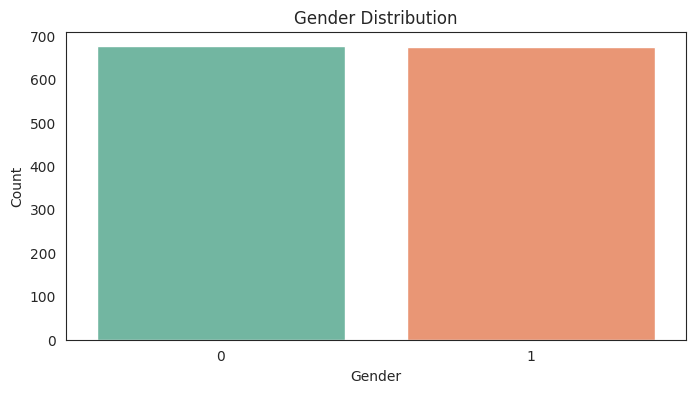

In [291]:
plt.figure(figsize=(8,4))
sns.countplot(data=data, x="Gender", palette="Set2")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

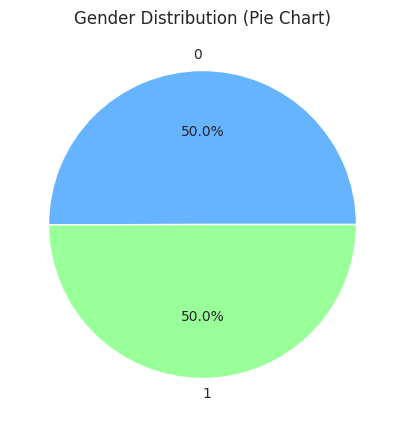

In [292]:
data['Gender'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(5,5),
    colors=['#66b3ff','#99ff99']
)

plt.title("Gender Distribution (Pie Chart)")
plt.ylabel("")

plt.show()

2. Hypertension Stages Distribution

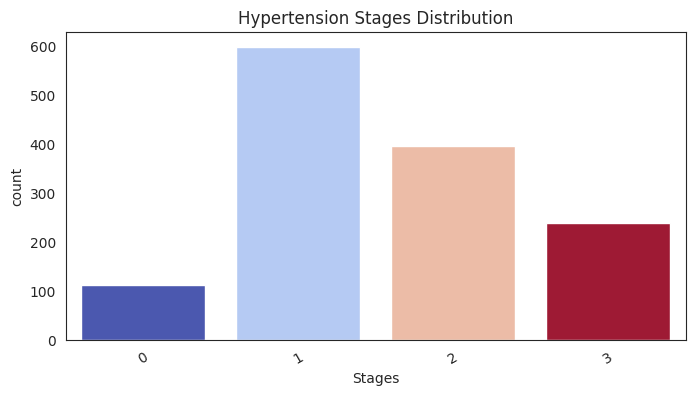

In [293]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=data,
    x="Stages",
    hue="Stages",
    palette="coolwarm",
    legend=False
)

plt.title("Hypertension Stages Distribution")
plt.xticks(rotation=30)

plt.show()

3. Correlation between Systolic and Diastolic Pressure

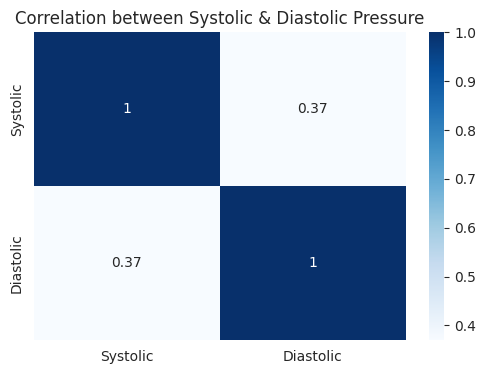

In [294]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(data[['Systolic','Diastolic']].corr(), annot=True, cmap="Blues")

plt.title("Correlation between Systolic & Diastolic Pressure")

plt.show()

4. TakeMedication vs. Severity

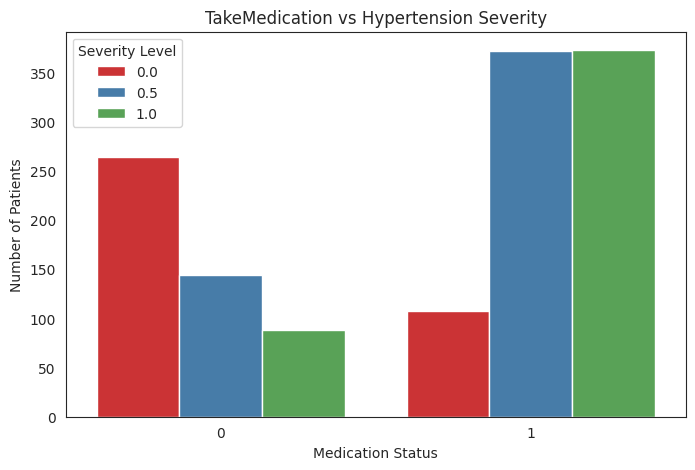

In [295]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="TakeMedication",
    hue="Severity",
    palette="Set1"
)

plt.title("TakeMedication vs Hypertension Severity")
plt.xlabel("Medication Status")
plt.ylabel("Number of Patients")

plt.legend(title="Severity Level")

plt.show()

5. Age Group vs. Hypertension Stages

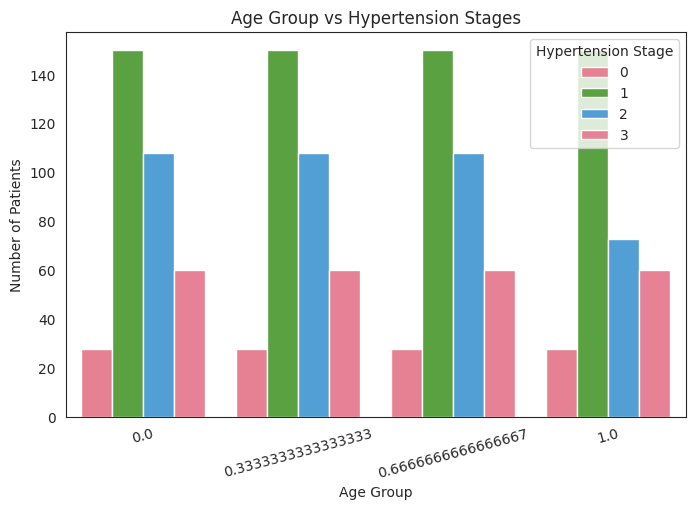

In [296]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="Age",
    hue="Stages",   # use this since it already contains text labels
    palette="husl"
)

plt.title("Age Group vs Hypertension Stages")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.xticks(rotation=15)

plt.legend(title="Hypertension Stage")

plt.show()

6. Pairplot: Systolic vs. Diastolic across Stages

In [297]:
print(data[['Systolic','Diastolic']].head())


   Systolic  Diastolic
0  0.333333   0.333333
1  0.333333   0.333333
2  0.333333   0.333333
3  0.333333   0.333333
4  0.333333   0.333333


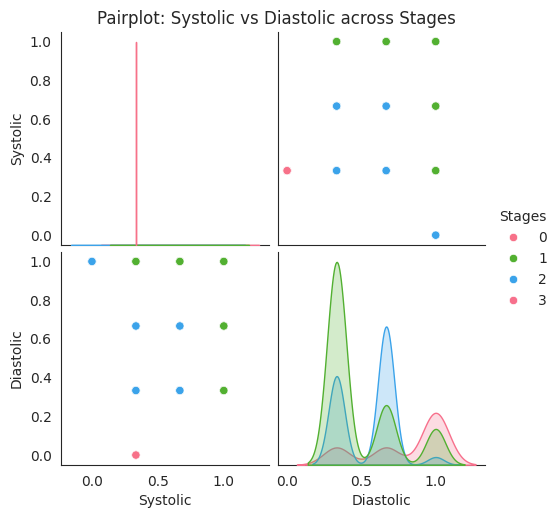

In [298]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    data[['Systolic','Diastolic','Stages']],
    hue='Stages',
    diag_kind='kde',
    palette='husl'
)

plt.suptitle("Pairplot: Systolic vs Diastolic across Stages", y=1.02)

plt.show()

# **Milestone 3: Model Building**

In [299]:
data['Stages'] = data['Stages'].replace({
    'HYPERTENSION (Stage-2).': 'HYPERTENSION (Stage-2)',
    'HYPERTENSIVE CRISI': 'HYPERTENSIVE CRISIS'
})

In [300]:
print(data['Stages'].value_counts())

Stages
1    600
2    397
3    240
0    112
Name: count, dtype: int64


In [301]:
from sklearn.model_selection import train_test_split

X = data.drop('Stages', axis=1)
y = data['Stages']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 1079
Testing set size: 270


**Algorithm Implementation and Comparison**

In [302]:
print(data.isnull().sum()[data.isnull().sum() > 0])

Series([], dtype: int64)


In [303]:
# ===============================
# Import Required Libraries
# ===============================

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = {}

# ===============================
# 1. Logistic Regression
# ===============================

log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print("\nLogistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['Logistic Regression'] = accuracy_score(y_test, y_pred)


# ===============================
# 2. Decision Tree
# ===============================

decisionTree = DecisionTreeClassifier()
decisionTree.fit(X_train, y_train)

y_pred = decisionTree.predict(X_test)

print("\nDecision Tree:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['Decision Tree'] = accuracy_score(y_test, y_pred)


# ===============================
# 3. Random Forest
# ===============================

randomforest = RandomForestClassifier()
randomforest.fit(X_train, y_train)

y_pred = randomforest.predict(X_test)

print("\nRandom Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['Random Forest'] = accuracy_score(y_test, y_pred)


# ===============================
# 4. Support Vector Machine
# ===============================

svm = SVC()
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("\nSupport Vector Machine:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['SVM'] = accuracy_score(y_test, y_pred)


# ===============================
# 5. K-Nearest Neighbors
# ===============================

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("\nK-Nearest Neighbors:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['KNN'] = accuracy_score(y_test, y_pred)


# ===============================
# 6. Ridge Classifier
# ===============================

RC = RidgeClassifier()
RC.fit(X_train, y_train)

y_pred = RC.predict(X_test)

print("\nRidge Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['Ridge Classifier'] = accuracy_score(y_test, y_pred)


# ===============================
# 7. Gaussian Naive Bayes
# ===============================

naive_bayes = GaussianNB()
naive_bayes.fit(X_train, y_train)

y_pred = naive_bayes.predict(X_test)

print("\nGaussian Naive Bayes:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['Naive Bayes'] = accuracy_score(y_test, y_pred)


# ===============================
# Model Accuracy Comparison
# ===============================

print("\n\nModel Accuracy Comparison")
print("--------------------------------")

for model, score in accuracy.items():
    print(model, ":", round(score*100,2), "%")


Logistic Regression:
Accuracy: 0.9481481481481482
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00       120
           2       1.00      0.82      0.90        80
           3       0.77      1.00      0.87        48

    accuracy                           0.95       270
   macro avg       0.94      0.96      0.94       270
weighted avg       0.96      0.95      0.95       270

Confusion Matrix:
 [[ 22   0   0   0]
 [  0 120   0   0]
 [  0   0  66  14]
 [  0   0   0  48]]

Decision Tree:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00       120
           2       1.00      1.00      1.00        80
           3       1.00      1.00      1.00        48

    accuracy                           1.00       270
   macro avg  

# **Milestone 4: Model Selection and Overfitting Analysis**

In [305]:
import pandas as pd

# Create dataframe from accuracy dictionary
comparison = pd.DataFrame(list(accuracy.items()), columns=["Algorithm", "Accuracy"])

# Convert accuracy to percentage
comparison["Accuracy"] = (comparison["Accuracy"]*100).round(1).astype(str) + "%"

# Add generalization assessment
comparison["Generalization Assessment"] = comparison["Algorithm"].map({
    "Decision Tree":"Overfitted",
    "Random Forest":"Overfitted",
    "SVM":"Overfitted",
    "KNN":"Good",
    "Logistic Regression":"Excellent",
    "Ridge Classifier":"Good",
    "Naive Bayes":"Good"
})

# Add selection status
comparison["Selection Status"] = comparison["Algorithm"].map({
    "Decision Tree":"Rejected",
    "Random Forest":"Rejected",
    "SVM":"Rejected",
    "KNN":"Considered",
    "Logistic Regression":"Selected",
    "Ridge Classifier":"Considered",
    "Naive Bayes":"Considered"
})

# Display table
comparison

,Algorithm,Accuracy,Generalization Assessment,Selection Status
0,Logistic Regression,94.8%,Excellent,Selected
1,Decision Tree,100.0%,Overfitted,Rejected
2,Random Forest,100.0%,Overfitted,Rejected
3,SVM,98.5%,Overfitted,Rejected
4,KNN,96.3%,Good,Considered
5,Ridge Classifier,88.5%,Good,Considered
6,Naive Bayes,84.8%,Good,Considered


# **Milestone 5 : Model Deployment and Web Application**

In [308]:
import joblib

# Save trained Logistic Regression model
joblib.dump(log_reg, "logreg_model.pkl")

print("✅ Model saved as logreg_model.pkl")
from google.colab import files
files.download("logreg_model.pkl")

✅ Model saved as logreg_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>